# Mine-Subsidence Early-Warning — End-to-End Walkthrough

**Sensor-based** ground-subsidence forecasting. No satellite / InSAR. Field nodes stream four channels:

| Channel | Meaning |
|---|---|
| `temp_c` | air temperature at the node |
| `humidity_pct` | relative humidity (saturation proxy) |
| `tilt_deg` | ground tilt magnitude |
| `distance_mm` | distance to a fixed overhead reference — **increasing ⇒ ground settling** |

**The label problem.** No public dataset carries those four channels *with a mine-subsidence risk label*, so we train on a
**CA DWR hybrid**:

| Channel in training data | Source | Real? |
|---|---|---|
| `distance_mm` | CA Dept. of Water Resources — *Ground-Surface Displacement / Land-Subsidence Monitoring* (extensometer cumulative settlement) | ✅ measured |
| `tilt_deg` | **derived**: `arctan(differential settlement between neighbouring stations / inter-station baseline)` — standard tiltmeter interpretation | ✅ derivation of measured data |
| `temp_c`, `humidity_pct`, `rain_mm` | Open-Meteo archive API (ERA5 reanalysis) at each station's coordinates | ✅ measured |
| **target** `y_reg` | forward settlement rate **in excess of the node's own trailing rate** (mm/day) — see §4 | rule-derived |

**Task = regression** (`labels.task` in `config/config.yaml`). Rather than a 3-class `safe/watch/critical` cut whose
boundary is an arbitrary quantile, the models predict the continuous excess-rate `y_reg` and are scored with
MAE / R² / Spearman **plus a recall-tuned operating point**. The 3-class labels are still computed; flip
`labels.task: classification` to get the old behaviour back.

This notebook runs every stage of `src/minesub/` in order, printing the intermediate tables so each step can be
explained on its own:

1. **Collect** — CA DWR displacement + Open-Meteo weather (with a labelled synthetic fallback)
2. **Build timeseries** — daily resample, tilt derivation, weather join
3. **Feature engineering** — backward 30-day window (+ Kalman-smoothed rate/accel) → feature vector; forward 21-day horizon → target signals
4. **Labels** — forward excess settlement rate → `y_reg`
5. **Temporal split** — earliest windows train, latest windows test (no leakage)
6. **Train** — Histogram-GBDT regressor (primary) + PyTorch LSTM regressor (secondary)
7. **Evaluate** — MAE / R² / Spearman, hazard-ranking PR curve, recall-tuned operating point, feature importance
8. **Live prediction** — feed a raw daily window through `minesub.predict`

## 0 — Setup

In [1]:
import os, sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ.setdefault("OMP_NUM_THREADS", "4")

# run from the repo root regardless of where Jupyter was launched
ROOT = Path().resolve()
while not (ROOT / "src" / "minesub").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
print("repo root :", ROOT)
print("python    :", sys.version.split()[0])

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)

from minesub.config import load_config
cfg = load_config()
cfg.ensure_dirs()
print("config    :", cfg.path)

repo root : /Users/anand/Documents/dev/SIH
python    : 3.11.16


config    : /Users/anand/Documents/dev/SIH/config/config.yaml


In [2]:
# --- the knobs that matter, pulled straight from config/config.yaml -------------
d = cfg["data"]; f = cfg["features"]; l = cfg["labels"]; s = cfg["split"]
TASK = l.get("task", "classification")
KF = f.get("kalman", {})
print("date range          :", d["min_date"], "->", d["max_date"])
print("displacement source :", d["ca_dwr"]["dataset_id"])
print("weather provider    :", d["weather"]["provider"])
print("synthetic fallback  :", d["allow_synthetic_fallback"], "(flag only; §1 confirms the real source)")
print("backward window     :", f["backward_window_days"], "days   (features look back)")
print("forward horizon     :", f["forward_horizon_days"], "days   (label looks ahead)")
print("window stride       :", f["step_days"], "days")
print("kalman features     :", KF.get("enabled", False),
      f'(process_var={KF.get("process_var")})' if KF.get("enabled") else "")
print("TASK                :", TASK)
print("split               :", s["method"], f'  val={s["val_fraction"]}  test={s["test_fraction"]}')
assert TASK == "regression", "this notebook is written for labels.task = regression"

date range          : 1992-01-01 -> 2026-08-23
displacement source : wdl-ground-surface-displacement-land-subsidence-monitoring
weather provider    : open-meteo
synthetic fallback  : True (flag only; §1 confirms the real source)
backward window     : 30 days   (features look back)
forward horizon     : 21 days   (label looks ahead)
window stride       : 7 days
kalman features     : True (process_var=0.001)
TASK                : regression
split               : temporal   val=0.15  test=0.2


In [3]:
# Rebuild every processed artifact from source in this notebook?
#   False -> reuse data/processed/*.parquet already in the repo (real CA DWR + Open-Meteo,
#            no network needed). Recommended for a demo / offline.
#   True  -> re-run minesub.data.build.build_timeseries live (needs internet for CA DWR
#            + Open-Meteo; falls back to the labelled synthetic surrogate if unreachable).
REBUILD_FROM_SOURCE = False

PROC = cfg.paths["processed"]
have_processed = (PROC / "timeseries.parquet").exists()
print("processed parquets present :", have_processed)
print("REBUILD_FROM_SOURCE        :", REBUILD_FROM_SOURCE)

processed parquets present : True
REBUILD_FROM_SOURCE        : False


## 1 — Data collection

Two real external inputs, each with a physical synthetic fallback. Code: [`src/minesub/data/sources.py`](../src/minesub/data/sources.py).

### 1a — CA DWR ground-surface displacement

`load_ground_displacement(cfg)`:

1. `GET {ckan_base}/package_show?id=...` on the **data.ca.gov CKAN** instance → lists the dataset's CSV resources.
2. Picks the **daily-timeseries** CSV (name contains `daily` / `timeseries` / …) and the **station-metadata** CSV
   (name contains `station`), then joins them for `lat` / `lon`.
3. `_normalise_displacement()` — maps whatever columns exist (`VERTICAL_DSP`, QC flag, …), keeps QC codes 1–2
   ("good data"), auto-detects the unit and scales to **mm**, and flips the sign so **subsidence is positive**.
4. Guard: if `< 3` stations or `< 500` rows survive → raise → fall back to the surrogate.

The download is cached in the repo as `data/raw/displacement-daily.csv` (the per-station timeseries) and
`data/raw/displacement-stations.csv` (station metadata). The cell below reproduces steps 2–3 **offline** from those
two files so the transformation is visible without a network call.

In [4]:
raw_ts = pd.read_csv("data/raw/displacement-daily.csv", low_memory=False)
raw_st = pd.read_csv("data/raw/displacement-stations.csv", low_memory=False)
print("displacement-daily.csv   :", raw_ts.shape, "  cols:", list(raw_ts.columns))
print("displacement-stations.csv:", raw_st.shape)
display(raw_ts.head(4))
display(raw_st[["STATION", "STNAME", "LATITUDE", "LONGITUDE", "COUNTY_NAME", "WELL_DEPTH"]].head(11))

displacement-daily.csv   : (98602, 4)   cols: ['STATION', 'MSMT_DATE', 'VERTICAL_DSP', 'VERTICAL_DSP_QC']
displacement-stations.csv: (11, 20)


,STATION,MSMT_DATE,VERTICAL_DSP,VERTICAL_DSP_QC
0,09N03E08C004M,1992-01-25,0.000,1
1,09N03E08C004M,1992-01-26,0.000,1
2,09N03E08C004M,1992-01-27,0.001,1
3,09N03E08C004M,1992-01-28,0.001,1


,STATION,STNAME,LATITUDE,LONGITUDE,COUNTY_NAME,WELL_DEPTH
0,09N03E08C004M,Conaway Extensometer screen 535-545 depth 716 ...,38.646430,-121.667384,Yolo,545.0
1,11N01E24Q008M,Zamora Land Subsidence Extensometer depth 1000...,38.779855,-121.812422,Yolo,NaN
2,11N04E04N005M,Sutter Land Subsidence Extensometer depth 1003...,38.823863,-121.543073,Sutter,NaN
3,16N02W05B001M,COL_05B001M screen interval 730 to 750 ft bgs,39.275273,-122.105677,Colusa,797.0
4,17N02W09H002M,COL_09H002M screen interval 779 to 800 bgs,39.341681,-122.083787,Colusa,806.0
5,18N01E35L001M,BUT_35L001M screen interval 816 to 836 bgs,39.367445,-121.827879,Butte,840.0
6,19N01E35B002M,BUT_35B002M screen interval 930 to 950 bgs,39.463439,-121.827750,Butte,980.0
7,19N02W08Q001M,GLE_08Q001M screen interval 856 to 876 bgs,39.515700,-122.112233,Glenn,910.0
8,20N01E18L001M,BUT_18L001M screen interval 767 to 894 bgs,39.577074,-121.908207,Butte,940.0
9,21N02W33M001M,GLE_33M001M screen interval 869 to 890 bgs,39.629906,-122.100662,Glenn,929.0


In [5]:
# reproduce minesub.data.sources._fetch_ca_dwr + _normalise_displacement, offline
from minesub.data.sources import _normalise_displacement, _pick

s_id  = _pick(list(raw_ts.columns), "station") or _pick(list(raw_ts.columns), "site")
st_id = _pick(list(raw_st.columns), "station") or _pick(list(raw_st.columns), "site")
c_lat = _pick(list(raw_st.columns), "lat")
c_lon = _pick(list(raw_st.columns), "lon") or _pick(list(raw_st.columns), "long")
print("column auto-pick -> ts station:", s_id, "| st station:", st_id, "| lat:", c_lat, "| lon:", c_lon)

merged = raw_ts.merge(
    raw_st[[st_id, c_lat, c_lon]].rename(columns={st_id: s_id}), on=s_id, how="left"
)
disp_real = _normalise_displacement(merged)
disp_real = disp_real[(disp_real["date"] >= d["min_date"]) & (disp_real["date"] <= d["max_date"])]
disp_real["data_source"] = "ca_dwr"

print("\nnormalised CA DWR displacement:", disp_real.shape,
      "|", disp_real["station_id"].nunique(), "stations",
      "|", disp_real["date"].min().date(), "->", disp_real["date"].max().date())
display(disp_real.head(4))

23:02:21  INFO     minesub.data.sources  QC filter kept 87880 / 93577 rows


23:02:21  INFO     minesub.data.sources  displacement unit scale -> mm: x304.8 (99p span=1.29 raw)


column auto-pick -> ts station: STATION | st station: STATION | lat: LATITUDE | lon: LONGITUDE

normalised CA DWR displacement: (87880, 7) | 11 stations | 1992-01-25 -> 2026-08-18


,station_id,date,lat,lon,qc,settlement_mm,data_source
0,09N03E08C004M,1992-01-25,38.64643,-121.667384,1,-0.0000,ca_dwr
1,09N03E08C004M,1992-01-26,38.64643,-121.667384,1,-0.0000,ca_dwr
2,09N03E08C004M,1992-01-27,38.64643,-121.667384,1,-0.3048,ca_dwr
3,09N03E08C004M,1992-01-28,38.64643,-121.667384,1,-0.3048,ca_dwr


In [6]:
# Whichever path the real repo takes, this is the same call the pipeline makes.
# Offline it will log "CA DWR unavailable ... using synthetic_fallback" and return the surrogate,
# which is itself worth showing: identical schema, every row tagged data_source="synthetic_fallback".
from minesub.data.sources import load_ground_displacement
disp_pipeline = load_ground_displacement(cfg)
print("returned:", disp_pipeline.shape, "| data_source values:", sorted(disp_pipeline["data_source"].unique()))
display(disp_pipeline.head(3))

23:02:26  INFO     minesub.data.sources  CA DWR timeseries resource 'Ground Surface Displacement - Daily Mean': (98602, 4)


23:02:27  INFO     minesub.data.sources  joined station coords (11 stations)


23:02:27  INFO     minesub.data.sources  QC filter kept 87880 / 93577 rows


23:02:27  INFO     minesub.data.sources  displacement unit scale -> mm: x304.8 (99p span=1.29 raw)


23:02:27  INFO     minesub.data.sources  CA DWR feed: 87880 rows, 11 stations


returned: (87880, 6) | data_source values: ['ca_dwr']


,station_id,date,lat,lon,settlement_mm,data_source
0,09N03E08C004M,1992-01-25,38.64643,-121.667384,-0.0000,ca_dwr
1,09N03E08C004M,1992-01-26,38.64643,-121.667384,-0.0000,ca_dwr
2,09N03E08C004M,1992-01-27,38.64643,-121.667384,-0.3048,ca_dwr


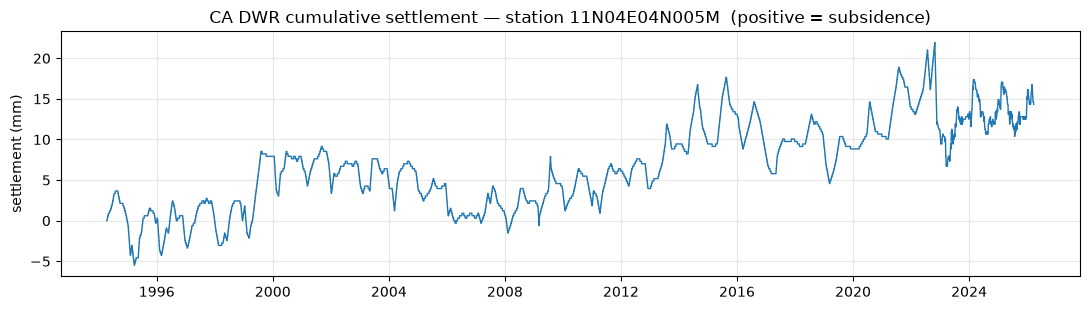

In [7]:
# one station's raw cumulative settlement (real CA DWR)
sid = disp_real["station_id"].value_counts().index[0]
g = disp_real[disp_real["station_id"] == sid].sort_values("date")
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(g["date"], g["settlement_mm"], lw=1)
ax.set_title(f"CA DWR cumulative settlement — station {sid}  (positive = subsidence)")
ax.set_ylabel("settlement (mm)"); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### 1b — Weather (temperature / humidity / rainfall)

`load_weather(cfg, stations)` — one HTTP call **per station** to Open-Meteo's archive API
(`archive-api.open-meteo.com/v1/archive`, ERA5 reanalysis, no API key), requesting
`temperature_2m_mean, relative_humidity_2m_mean, precipitation_sum`. Each response is cached as a CSV under
`data/raw/weather/`. Provider fallback order: **Open-Meteo → Meteostat → seasonal model**.

The repo already has one cached CSV per station (`data/raw/weather/openmeteo_<station>_<start>_<end>.csv`), so this
runs offline straight from cache.

In [8]:
wx_files = sorted((cfg.paths["raw"] / "weather").glob("*.csv"))
print(len(wx_files), "cached weather files, e.g.:", wx_files[0].name)
one = pd.read_csv(wx_files[0], parse_dates=["date"])
display(one.head(4))
print(one.describe().loc[["mean", "min", "max"]].round(2).to_string())

22 cached weather files, e.g.: openmeteo_09N03E08C004M_19920101_20260823.csv


,date,temp_c,humidity_pct,rain_mm
0,1992-01-01,7.1,82,0.0
1,1992-01-02,6.8,78,0.0
2,1992-01-03,6.9,77,0.0
3,1992-01-04,9.6,84,4.8


                     date  temp_c  humidity_pct  rain_mm
mean  2009-04-27 12:00:00   16.99         59.75     1.57
min   1992-01-01 00:00:00    0.60          8.00     0.00
max   2026-08-23 00:00:00   35.30         97.00    88.20


23:02:28  INFO     minesub.data.sources  weather: 139194 rows; stations by source: {'open-meteo': 11}


weather rows: (139194, 6) | sources: ['open-meteo']


,station_id,date,temp_c,humidity_pct,rain_mm,data_source
0,09N03E08C004M,1992-01-01,7.1,82,0.0,open-meteo
1,09N03E08C004M,1992-01-02,6.8,78,0.0,open-meteo
2,09N03E08C004M,1992-01-03,6.9,77,0.0,open-meteo
3,09N03E08C004M,1992-01-04,9.6,84,4.8,open-meteo


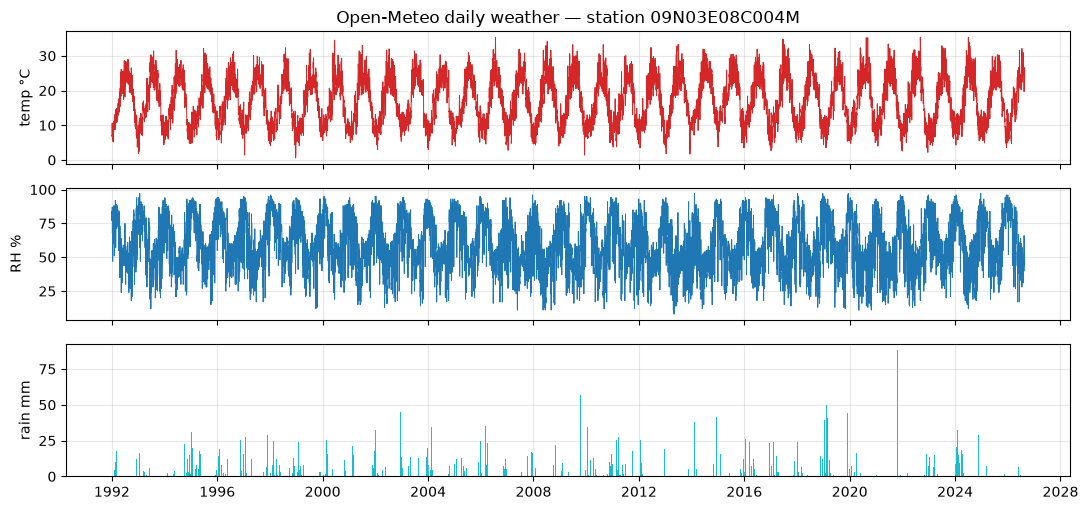

In [9]:
from minesub.data.sources import load_weather

# station table the weather loader needs: station_id, lat, lon
stations = (disp_real.groupby("station_id")[["lat", "lon"]].first().reset_index())
wx = load_weather(cfg, stations)
print("weather rows:", wx.shape, "| sources:", sorted(wx["data_source"].unique()))
display(wx.head(4))

sid_wx = wx["station_id"].iloc[0]
gw = wx[wx["station_id"] == sid_wx].sort_values("date")
fig, ax = plt.subplots(3, 1, figsize=(11, 5.2), sharex=True)
ax[0].plot(gw["date"], gw["temp_c"], lw=.7, color="tab:red");   ax[0].set_ylabel("temp °C")
ax[1].plot(gw["date"], gw["humidity_pct"], lw=.7, color="tab:blue"); ax[1].set_ylabel("RH %")
ax[2].bar(gw["date"], gw["rain_mm"], width=2, color="tab:cyan");  ax[2].set_ylabel("rain mm")
ax[0].set_title(f"Open-Meteo daily weather — station {sid_wx}")
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2 — Build the per-station daily timeseries

Code: [`src/minesub/data/build.py`](../src/minesub/data/build.py). `build_timeseries(cfg)`:

1. **`_resample_daily`** — resample each station to a daily `distance_mm` (cumulative settlement), interpolating gaps.
2. **`_derive_tilt`** — for each station find its nearest neighbour (haversine distance); the baseline is the
   inter-station distance. `tilt = arctan(Δsettlement / baseline)`. Isolated stations use the gradient vs. the
   regional mean over a nominal 1 km baseline. Adds ±0.003° independent per-reading noise so tilt is **not** a
   deterministic function of `distance_mm`.
3. **Weather join** on `(station_id, date)`; edge gaps interpolated; `rain_mm` gaps → 0.

Output: `data/processed/timeseries.parquet` — one row per station per day.

In [10]:
from minesub.data.build import build_timeseries

if REBUILD_FROM_SOURCE or not have_processed:
    print(">>> rebuilding timeseries.parquet from source ...")
    ts = build_timeseries(cfg, save=True)
else:
    ts = pd.read_parquet(PROC / "timeseries.parquet")
    print(">>> loaded existing data/processed/timeseries.parquet")

print("\ntimeseries:", ts.shape, "|", ts["station_id"].nunique(), "stations |",
      ts["date"].min().date(), "->", ts["date"].max().date())
print("displacement source(s):", sorted(ts["data_source_disp"].unique()),
      "| weather source(s):", sorted(ts["data_source_wx"].unique()))
display(ts.head(4))

>>> loaded existing data/processed/timeseries.parquet

timeseries: (96801, 11) | 11 stations | 1992-10-21 -> 2026-08-18
displacement source(s): ['ca_dwr'] | weather source(s): ['open-meteo']


,station_id,date,distance_mm,lat,lon,data_source_disp,tilt_deg,temp_c,humidity_pct,rain_mm,data_source_wx
0,09N03E08C004M,1992-10-21,24.0792,38.64643,-121.667384,ca_dwr,-0.002093,18.8,77,13.0,open-meteo
1,09N03E08C004M,1992-10-22,23.4696,38.64643,-121.667384,ca_dwr,0.001020,17.9,65,0.0,open-meteo
2,09N03E08C004M,1992-10-23,23.1648,38.64643,-121.667384,ca_dwr,-0.000221,19.0,57,0.0,open-meteo
3,09N03E08C004M,1992-10-24,22.5552,38.64643,-121.667384,ca_dwr,0.006350,19.8,52,0.0,open-meteo


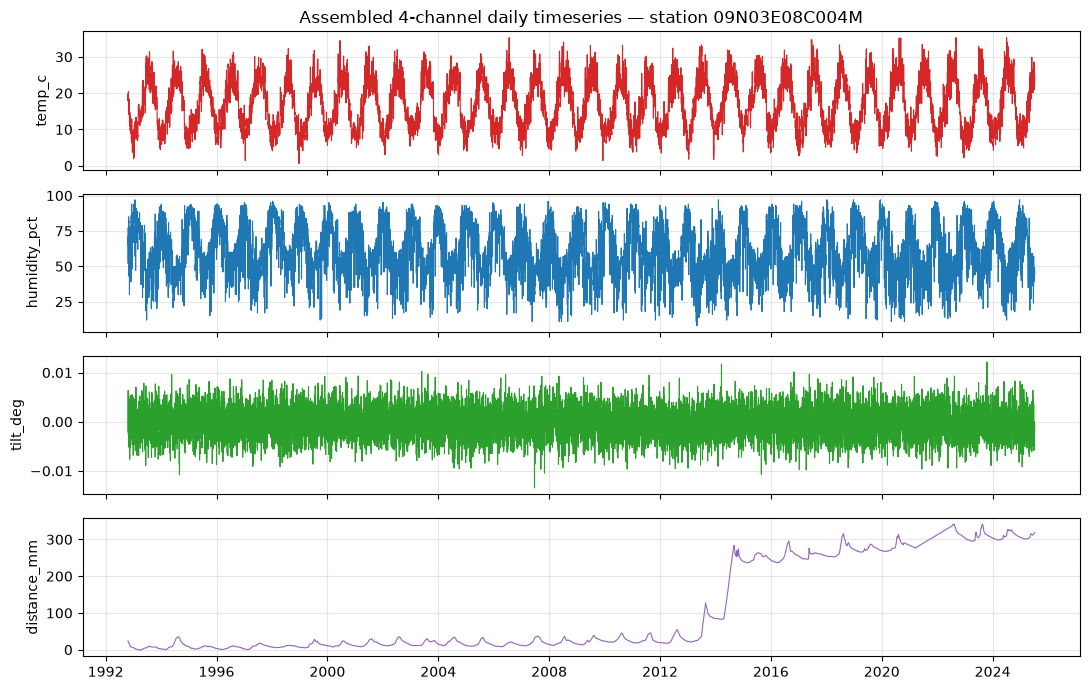

In [11]:
# all four channels for one station — this is exactly what a field node streams
sid = ts["station_id"].value_counts().index[0]
g = ts[ts["station_id"] == sid].sort_values("date")
fig, ax = plt.subplots(4, 1, figsize=(11, 7), sharex=True)
for a, col, c in zip(ax, ["temp_c", "humidity_pct", "tilt_deg", "distance_mm"],
                     ["tab:red", "tab:blue", "tab:green", "tab:purple"]):
    a.plot(g["date"], g[col], lw=.8, color=c); a.set_ylabel(col); a.grid(alpha=.3)
ax[0].set_title(f"Assembled 4-channel daily timeseries — station {sid}")
plt.tight_layout(); plt.show()

## 3 — Feature engineering (windowing)

Code: [`src/minesub/features.py`](../src/minesub/features.py). For each station, slide a window whose end-point
advances by `step_days` (7). At each end-point `t`:

* **backward window** `[t-29, t]` → the feature vector: last value, delta, linear **rate** (slope/day),
  **acceleration**, rolling std/range for `distance` & `tilt`; mean/delta/std for humidity & temperature; rainfall
  sums; day-of-year `sin`/`cos`. *This is all a node has observed so far.*
* **+ Kalman features** (when `features.kalman.enabled`) — a constant-acceleration Kalman smoother
  ([`src/minesub/kalman.py`](../src/minesub/kalman.py)) on `distance_mm` / `tilt_deg` adds `dist_kf_rate`,
  `dist_kf_accel`, `dist_kf_level`, `dist_kf_rate_std`, `dist_kf_rate_delta`, `tilt_kf_rate`, `tilt_kf_accel` —
  cleaner rate/accel than the polyfit slopes, still computed online (deployable on a node).
* **forward horizon** `[t+1, t+21]` (7-day-smoothed) → `fwd_settlement_rate`, `fwd_settlement_accel`,
  `fwd_tilt_rate`. **Never fed to the model** — used only to build `y_reg` in step 4.

Output: `data/processed/samples.parquet`.

In [12]:
from minesub.features import build_feature_table, feature_columns

if REBUILD_FROM_SOURCE or not (PROC / "samples.parquet").exists():
    samples = build_feature_table(cfg, ts=ts, save=True)
else:
    samples = pd.read_parquet(PROC / "samples.parquet")
    print(">>> loaded existing data/processed/samples.parquet")

feat_cols = feature_columns(samples)
kf_cols   = [c for c in feat_cols if "_kf_" in c]
fwd_cols  = [c for c in samples.columns if c.startswith("fwd_")]
print("samples:", samples.shape, "|", samples["station_id"].nunique(), "stations |",
      samples["t"].min().date(), "->", samples["t"].max().date())
print("\n%d model features (%d Kalman-derived):" % (len(feat_cols), len(kf_cols)))
print(feat_cols)
print("\nforward-horizon target signals (NOT features):", fwd_cols)
display(samples[["station_id", "t"] + feat_cols[:8]].head(4))

>>> loaded existing data/processed/samples.parquet
samples: (13754, 40) | 11 stations | 1992-11-19 -> 2026-07-26

32 model features (7 Kalman-derived):
['days_since_start', 'distance_last', 'distance_delta', 'distance_rate', 'distance_accel', 'distance_std', 'distance_range', 'tilt_last', 'tilt_delta', 'tilt_rate', 'tilt_accel', 'tilt_std', 'tilt_abs_last', 'humidity_mean', 'humidity_delta', 'humidity_std', 'temp_mean', 'temp_range', 'temp_std', 'rain_sum', 'rain_max', 'rain_recent7', 'rain_days', 'doy_sin', 'doy_cos', 'dist_kf_level', 'dist_kf_rate', 'dist_kf_accel', 'dist_kf_rate_std', 'dist_kf_rate_delta', 'tilt_kf_rate', 'tilt_kf_accel']

forward-horizon target signals (NOT features): ['fwd_settlement_rate', 'fwd_settlement_accel', 'fwd_tilt_rate']


,station_id,t,days_since_start,distance_last,distance_delta,distance_rate,distance_accel,distance_std,distance_range,tilt_last
0,09N03E08C004M,1992-11-19,29.0,10.0584,-14.0208,-0.502869,-0.005449,4.360806,14.0208,0.001041
1,11N01E24Q008M,1992-11-19,29.0,-9.4488,-9.1440,-0.319447,0.000981,2.766077,9.1440,-0.001805
2,09N03E08C004M,1992-11-26,36.0,9.1440,-11.8872,-0.451199,0.016307,3.962192,11.8872,-0.000945
3,11N01E24Q008M,1992-11-26,36.0,-10.6680,-8.2296,-0.290086,0.006835,2.522955,8.2296,-0.001950


In [13]:
# one sample, fully unpacked: backward features vs the forward signals it is labelled from
r = samples.iloc[len(samples) // 2]
print(f"station {r['station_id']}  window end t = {r['t'].date()}\n")
print("-- backward-window features (fed to the model) --")
for c in feat_cols:
    tag = "  (kalman)" if "_kf_" in c else ""
    print(f"  {c:22s} {r[c]:+.4f}{tag}")
print("\n-- forward-horizon signals (used only for the label) --")
for c in fwd_cols:
    print(f"  {c:22s} {r[c]:+.4f}")

station 11N04E04N005M  window end t = 2014-05-09

-- backward-window features (fed to the model) --
  days_since_start       +7330.0000
  distance_last          +9.7536
  distance_delta         +1.5240
  distance_rate          +0.0536
  distance_accel         +0.0065
  distance_std           +0.5181
  distance_range         +1.5240
  tilt_last              +0.0027
  tilt_delta             +0.0056
  tilt_rate              +0.0001
  tilt_accel             -0.0000
  tilt_std               +0.0033
  tilt_abs_last          +0.0027
  humidity_mean          +50.8333
  humidity_delta         +3.0000
  humidity_std           +10.4438
  temp_mean              +18.3333
  temp_range             +12.4000
  temp_std               +2.6428
  rain_sum               +14.3000
  rain_max               +6.9000
  rain_recent7           +0.0000
  rain_days              +2.0000
  doy_sin                +0.7971
  doy_cos                -0.6038
  dist_kf_level          +9.8236  (kalman)
  dist_kf_rate          

## 4 — Label: the regression target `y_reg`

Code: [`src/minesub/labels.py`](../src/minesub/labels.py). Early warning is about **deviation from a node's own
recent behaviour**, not its absolute rate (a slow-but-steady station is not an alert). The target is

```
y_reg = fwd_settlement_rate  -  distance_rate      (forward excess settlement rate, mm/day)
```

i.e. how much faster the ground settles over the next 21 days than the node's own trailing 30-day rate. The forward
window is 7-day-smoothed so `y_reg` reflects sustained deformation, not a blip. `y_reg` is **zero-centred with a
right tail**: most windows show no acceleration; a few show a lot. `add_risk_labels` also still writes the 3-class
`risk_class` for reference. Output: `data/processed/samples_labeled.parquet`.

>>> loaded existing data/processed/samples_labeled.parquet
y_reg (mm/day excess)  median 0.0000  p75 0.0281  p90 0.0952  p95 0.1671  p99 0.4984
                        mean -0.0002  std 0.1623  min -2.5929  max 1.5962

(reference) 3-class counts: {'safe': 8252, 'watch': 4126, 'critical': 1376}


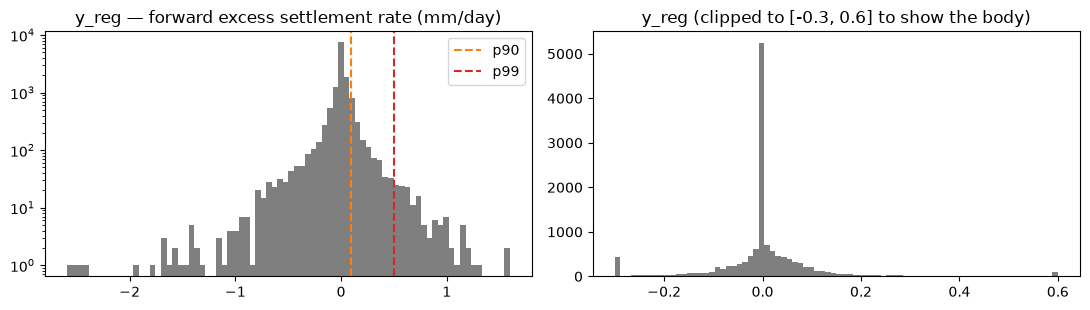

In [14]:
from minesub.labels import add_risk_labels
from minesub import RISK_CLASSES

if REBUILD_FROM_SOURCE or not (PROC / "samples_labeled.parquet").exists():
    labeled = add_risk_labels(cfg, samples, save=True)
else:
    labeled = pd.read_parquet(PROC / "samples_labeled.parquet")
    print(">>> loaded existing data/processed/samples_labeled.parquet")

yv = labeled["y_reg"].to_numpy()
q = np.quantile(yv, [.5, .75, .9, .95, .99])
print("y_reg (mm/day excess)  median %.4f  p75 %.4f  p90 %.4f  p95 %.4f  p99 %.4f" % tuple(q))
print("                        mean %.4f  std %.4f  min %.4f  max %.4f"
      % (yv.mean(), yv.std(), yv.min(), yv.max()))
cnts = labeled["risk_class"].value_counts().reindex(RISK_CLASSES)
print("\n(reference) 3-class counts:", {k: int(v) for k, v in cnts.items()})

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(yv, bins=80, color="tab:gray"); ax[0].set_yscale("log")
ax[0].axvline(q[2], color="tab:orange", ls="--", label="p90")
ax[0].axvline(q[4], color="tab:red", ls="--", label="p99")
ax[0].set_title("y_reg — forward excess settlement rate (mm/day)"); ax[0].legend()
ax[1].hist(np.clip(yv, -0.3, 0.6), bins=80, color="tab:gray")
ax[1].set_title("y_reg (clipped to [-0.3, 0.6] to show the body)")
plt.tight_layout(); plt.show()

## 5 — Temporal train / val / test split

Code: [`src/minesub/datasplit.py`](../src/minesub/datasplit.py). Rank every sample by its window end-point `t`;
the **earliest 65 %** train, the **next 15 %** validate, the **latest 20 %** test. A pure time cut — the model is
always tested on windows that end *after* everything it trained on, so a forward-horizon label can never leak back.

In [15]:
from minesub.datasplit import temporal_split
tr, va, te = temporal_split(cfg, labeled)
y = labeled["y_reg"].to_numpy()

for name, m in [("train", tr), ("val", va), ("test", te)]:
    tt = labeled.loc[m, "t"]; yy = y[m]
    print(f"{name:5s}  n={m.sum():5d}   {tt.min().date()} -> {tt.max().date()}   "
          f"y_reg mean {yy.mean():+.4f}  p90 {np.quantile(yy, .9):.4f}  p99 {np.quantile(yy, .99):.4f}")

23:02:32  INFO     minesub.datasplit  split: train=8940 (<2017-12-10)  val=2063  test=2751 (>=2021-07-16)


train  n= 8940   1992-11-19 -> 2017-12-10   y_reg mean -0.0004  p90 0.0987  p99 0.5055
val    n= 2063   2017-12-10 -> 2021-07-16   y_reg mean +0.0005  p90 0.0880  p99 0.6154
test   n= 2751   2021-07-16 -> 2026-07-26   y_reg mean -0.0003  p90 0.0865  p99 0.3772


## 6 — Train the models

Code: [`src/minesub/train.py`](../src/minesub/train.py), [`src/minesub/models/`](../src/minesub/models/).
`train(cfg, name)` reads the labelled samples, applies the temporal split, fits on `y_reg`, scores the **test**
split with `evaluate_regression`, and writes `artifacts/models/` + `reports/metrics_<name>.json` +
`reports/regression_<name>.png`.

| Model | Algorithm | Input |
|---|---|---|
| `gbdt` (primary) | `HistGradientBoostingRegressor` (absolute-error loss), early stopping | the windowed feature vector (+ Kalman) |
| `torch` (secondary) | 2-layer LSTM + MLP head → 1 output, Huber loss | raw `[30, 4]` daily sequence, window-detrended |

> `metrics_*.json` carry `"synthetic_data": true/false`. On the synthetic surrogate the numbers only exercise the
> pipeline — they are not a benchmark.

In [16]:
from minesub.train import train

metrics = {}
for name in ("gbdt", "torch"):
    print(f"\n{'='*70}\n  TRAIN  {name}\n{'='*70}")
    metrics[name] = train(cfg, name)

# train() -> evaluate._plot_* switches matplotlib to the Agg backend;
# restore the inline backend so the plots in the cells below render in the notebook.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass


  TRAIN  gbdt


23:02:34  INFO     minesub.datasplit  split: train=8940 (<2017-12-10)  val=2063  test=2751 (>=2021-07-16)


23:02:34  INFO     minesub.train  task=regression  model=gbdt


23:02:35  INFO     minesub.models.gbdt  trained (regression); n_iter=600 (of max 600)


23:02:38  INFO     minesub.models.gbdt  saved -> /Users/anand/Documents/dev/SIH/artifacts/models/gbdt.joblib


...

23:02:56  INFO     minesub.models.torch  done; best val_MAE=0.0550  device=mps


23:02:56  INFO     minesub.models.torch  saved -> /Users/anand/Documents/dev/SIH/artifacts/models/lstm.pt


23:02:56  INFO     minesub.evaluate  wrote /Users/anand/Documents/dev/SIH/reports/regression_torch.png


23:02:56  INFO     minesub.evaluate  [torch] MAE=0.0513  R2=0.377  spearman=0.521  PR-AUC(hazard)=0.358  | op: recall=0.60 precision=0.20 flag=30.6%


23:02:56  INFO     minesub.evaluate  wrote /Users/anand/Documents/dev/SIH/reports/metrics_torch.json


In [17]:
def show(m):
    c = m.get("chosen_operating_point") or {}
    return {
        "n_test":        m["n_samples"],
        "MAE":           round(m["mae"], 4),
        "RMSE":          round(m["rmse"], 4),
        "R2":            round(m["r2"], 3),
        "Pearson_r":     round(m["pearson_r"], 3),
        "Spearman_rho":  round(m["spearman_rho"], 3),
        "hazard_PR_AUC": round(m["hazard_pr_auc"], 3),
        "op_recall":     round(c.get("recall", float("nan")), 2),
        "op_precision":  round(c.get("precision", float("nan")), 2),
        "op_flag_frac":  round(c.get("flagged_frac", float("nan")), 3),
        "synthetic":     m.get("synthetic_data"),
    }
pd.DataFrame({k: show(v) for k, v in metrics.items()}).T

,n_test,MAE,RMSE,R2,Pearson_r,Spearman_rho,hazard_PR_AUC,op_recall,op_precision,op_flag_frac,synthetic
gbdt,2751,0.0484,0.1072,0.389,0.624,0.559,0.483,0.6,0.45,0.136,False
torch,2751,0.0513,0.1082,0.377,0.615,0.521,0.358,0.6,0.2,0.306,False


### 6b — Inside the LSTM (the neural network)

`train(cfg, "torch")` hides the model behind one call. Here it is, unpacked. Code:
[`src/minesub/models/torch_model.py`](../src/minesub/models/torch_model.py).

```
input   x : [batch, 30, 4]           30 daily steps · (temp_c, humidity_pct, tilt_deg, distance_mm)
            tilt & distance are detrended to the window's first value; all 4 channels are then
            standardised with train-set mean/std.

  nn.LSTM(input_size=4, hidden_size=64, num_layers=2, batch_first=True, dropout=0.2)
        └─ take the hidden state at the LAST timestep  ->  [batch, 64]

  head:  LayerNorm(64) -> Linear(64->32) -> ReLU -> Dropout(0.2) -> Linear(32->1)
        └─ 1 output  ->  de-standardised  ->  predicted y_reg (mm/day excess)
```

Loss: **Huber / SmoothL1** on the standardised target (Adam, lr 1e-3, weight-decay 1e-4, grad-clip 5). Training
keeps the epoch with the lowest **validation MAE** and early-stops after `patience=10` epochs without improvement.

In [18]:
import torch
from minesub.models.torch_model import _LSTMNet, LSTMRiskModel
from minesub.features import build_sequences, RAW_CHANNELS

p = cfg["model"]["torch"]
net = _LSTMNet(n_ch=len(RAW_CHANNELS), hidden=int(p["hidden_size"]),
               layers=int(p["num_layers"]), dropout=float(p["dropout"]), n_cls=1)  # n_cls=1 -> regression head
print(net)
tot = sum(x.numel() for x in net.parameters())
print(f"\ntrainable parameters: {tot:,}\n")
for pname, prm in net.named_parameters():
    print(f"  {pname:32s} {str(tuple(prm.shape)):18s} {prm.numel():>8,}")

_LSTMNet(
  (lstm): LSTM(4, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

trainable parameters: 53,441

  lstm.weight_ih_l0                (256, 4)              1,024
  lstm.weight_hh_l0                (256, 64)            16,384
  lstm.bias_ih_l0                  (256,)                  256
  lstm.bias_hh_l0                  (256,)                  256
  lstm.weight_ih_l1                (256, 64)            16,384
  lstm.weight_hh_l1                (256, 64)            16,384
  lstm.bias_ih_l1                  (256,)                  256
  lstm.bias_hh_l1                  (256,)                  256
  head.0.weight                    (64,)                    64
  head.0.bias                      (64,)          

sequence tensor : (13754, 30, 4)  = (samples, seq_len=30, channels=4)
channels        : ['temp_c', 'humidity_pct', 'tilt_deg', 'distance_mm']
train/val/test  : (8940, 30, 4) (2063, 30, 4) (2751, 30, 4)


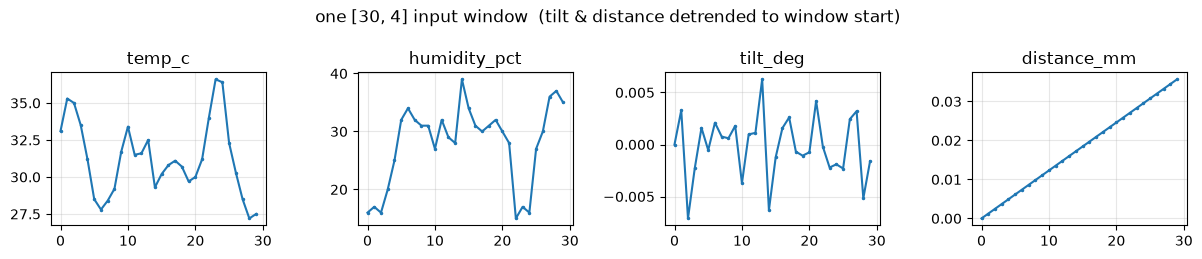

In [19]:
# the raw tensor the network actually sees: one [30, 4] window per sample
seq = build_sequences(cfg, labeled, ts)
print("sequence tensor :", seq.shape, " = (samples, seq_len=30, channels=4)")
print("channels        :", RAW_CHANNELS)
print("train/val/test  :", seq[tr].shape, seq[va].shape, seq[te].shape)

i = np.where(te)[0][0]
w = seq[i]
fig, ax = plt.subplots(1, 4, figsize=(12, 2.6))
for k, ch in enumerate(RAW_CHANNELS):
    ax[k].plot(w[:, k], marker=".", ms=3); ax[k].set_title(ch); ax[k].grid(alpha=.3)
fig.suptitle("one [30, 4] input window  (tilt & distance detrended to window start)")
plt.tight_layout(); plt.show()

23:03:01  INFO     minesub.models.torch  epoch   1  val_MAE=0.0655  (best=0.0655)


23:03:01  INFO     minesub.models.torch  epoch   2  val_MAE=0.0624  (best=0.0624)


23:03:01  INFO     minesub.models.torch  epoch   3  val_MAE=0.0584  (best=0.0584)


23:03:02  INFO     minesub.models.torch  epoch   4  val_MAE=0.0582  (best=0.0582)


23:03:02  INFO     minesub.models.torch  epoch   5  val_MAE=0.0571  (best=0.0571)


...

23:03:09  INFO     minesub.models.torch  epoch  20  val_MAE=0.0550  (best=0.0550)


23:03:12  INFO     minesub.models.torch  epoch  25  val_MAE=0.0585  (best=0.0550)


23:03:14  INFO     minesub.models.torch  epoch  30  val_MAE=0.0587  (best=0.0550)


23:03:14  INFO     minesub.models.torch  early stop at epoch 30


23:03:14  INFO     minesub.models.torch  done; best val_MAE=0.0550  device=mps


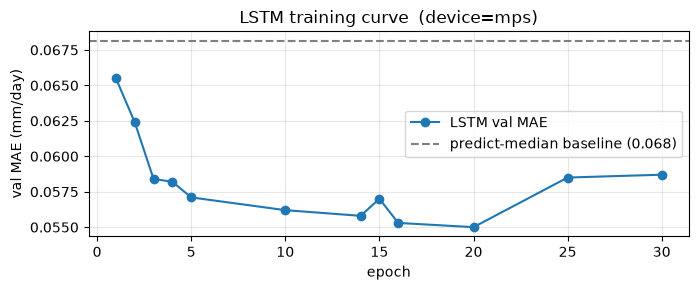

In [20]:
# watch the network learn: re-fit on the same split, capture val MAE per logged epoch
import logging, re
hist = []
class _Grab(logging.Handler):
    def emit(self, rec):
        m = re.search(r"epoch\s+(\d+)\s+val_MAE=([\d.]+)", rec.getMessage())
        if m: hist.append((int(m.group(1)), float(m.group(2))))
_lg = logging.getLogger("minesub.models.torch"); _h = _Grab(); _lg.addHandler(_h)

demo = LSTMRiskModel(cfg, task="regression")
demo.fit(seq[tr], y[tr], seq[va], y[va])
_lg.removeHandler(_h)

ep, mae = zip(*hist)
naive = float(np.mean(np.abs(y[va] - np.median(y[tr]))))
plt.figure(figsize=(7, 3))
plt.plot(ep, mae, marker="o", label="LSTM val MAE")
plt.axhline(naive, ls="--", color="gray", label=f"predict-median baseline ({naive:.3f})")
plt.xlabel("epoch"); plt.ylabel("val MAE (mm/day)")
plt.title(f"LSTM training curve  (device={demo.device})"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [21]:
# a real forward pass: load the trained net, push 8 test windows through it
m = LSTMRiskModel.load(cfg, cfg.paths["models"] / "lstm.pt")
print("input  standardisation  mu:", np.round(m.mu, 3))
print("                        sd:", np.round(m.sd, 3))
print("target standardisation  y_mu: %.4f   y_sd: %.4f\n" % (m.y_mu, m.y_sd))

idx = np.where(te)[0][:8]
pred = m.predict(seq[idx])
fwd = pd.DataFrame({
    "station":       labeled.iloc[idx]["station_id"].to_numpy(),
    "t":             labeled.iloc[idx]["t"].dt.date.to_numpy(),
    "pred_y_reg":    np.round(pred, 4),
    "true_y_reg":    np.round(y[idx], 4),
    "abs_err":       np.round(np.abs(pred - y[idx]), 4),
})
fwd

input  standardisation  mu: [17.728 53.595  0.     0.128]
                        sd: [7.6460e+00 2.0449e+01 4.0000e-03 3.4220e+00]
target standardisation  y_mu: -0.0004   y_sd: 0.1672



,station,t,pred_y_reg,true_y_reg,abs_err
0,21N02W33M001M,2021-07-16,-0.0025,-0.0001,0.0024
1,11N04E04N005M,2021-07-16,-0.1113,-0.0498,0.0615
2,16N02W05B001M,2021-07-18,-0.2682,-0.1707,0.0976
3,17N02W09H002M,2021-07-18,-0.1133,-0.2175,0.1042
4,18N01E35L001M,2021-07-18,-0.0021,0.0000,0.0021
5,19N01E35B002M,2021-07-18,-0.0021,0.0058,0.0079
6,09N03E08C004M,2021-07-22,-0.1633,-0.0092,0.1540
7,22N02W15C002M,2021-07-22,-0.1006,-0.1550,0.0544


## 7 — Evaluate: predicted-vs-true, hazard-ranking operating point, feature importance

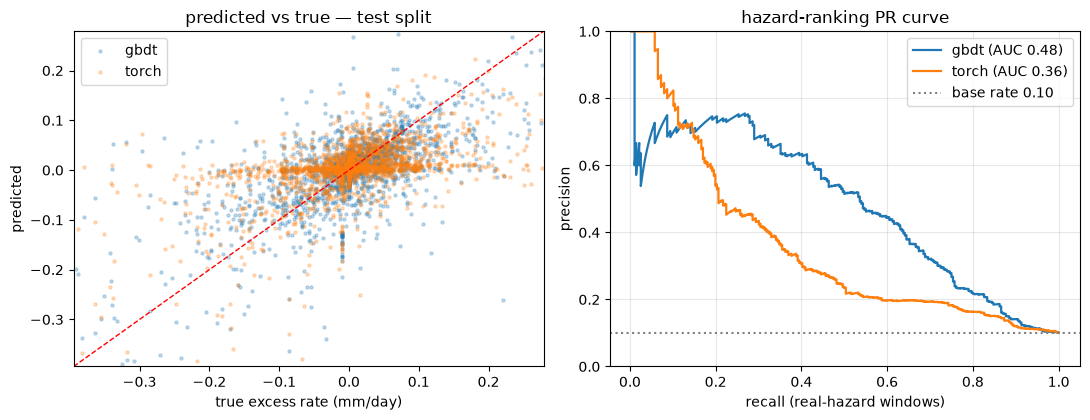

In [22]:
from minesub.models.gbdt_model import GbdtRiskModel

Xte = labeled[feat_cols].to_numpy(float)[te]
yte = y[te]
pred = {
    "gbdt":  GbdtRiskModel.load(cfg, cfg.paths["models"] / "gbdt.joblib").predict(Xte),
    "torch": m.predict(seq[te]),
}
top_frac = cfg.get("evaluate", {}).get("hazard_top_frac", 0.10)
thr_true = np.quantile(yte, 1 - top_frac)
pos = yte >= thr_true          # "real hazard" = top 10% of the true excess rate

fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
lim = np.percentile(np.concatenate([yte, pred["gbdt"], pred["torch"]]), [1, 99])
for name, col in [("gbdt", "tab:blue"), ("torch", "tab:orange")]:
    ax[0].scatter(yte, pred[name], s=5, alpha=.25, color=col, label=name)
    order = np.argsort(-pred[name]); ps = pos[order]
    tp = np.cumsum(ps); fp = np.cumsum(~ps)
    rec = tp / max(pos.sum(), 1); prc = tp / np.maximum(tp + fp, 1)
    ax[1].plot(rec, prc, color=col, lw=1.6, label=f"{name} (AUC {metrics[name]['hazard_pr_auc']:.2f})")
ax[0].plot(lim, lim, "r--", lw=1); ax[0].set_xlim(*lim); ax[0].set_ylim(*lim)
ax[0].set_xlabel("true excess rate (mm/day)"); ax[0].set_ylabel("predicted")
ax[0].set_title("predicted vs true — test split"); ax[0].legend()
ax[1].axhline(pos.mean(), color="gray", ls=":", label=f"base rate {pos.mean():.2f}")
ax[1].set_xlabel("recall (real-hazard windows)"); ax[1].set_ylabel("precision")
ax[1].set_ylim(0, 1); ax[1].set_title("hazard-ranking PR curve"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [23]:
# operating points: the score threshold that first reaches each target recall
def op_table(mm):
    rows = {}
    for k, v in mm["operating_points"].items():
        rows[k] = ({"precision": round(v["precision"], 3), "recall": round(v["recall"], 3),
                    "windows_flagged": f"{v['flagged_frac']*100:.1f}%",
                    "threshold_mm_day": round(v["threshold"], 4)} if v else
                   {"precision": None, "recall": None, "windows_flagged": None, "threshold_mm_day": None})
    return pd.DataFrame(rows).T

print("GBDT — operating points")
display(op_table(metrics["gbdt"]))
print("GBDT — precision @ top-k fraction of windows")
display(pd.DataFrame(metrics["gbdt"]["precision_at_topk"]).T.round(3))

GBDT — operating points


,precision,recall,windows_flagged,threshold_mm_day
recall>=0.5,0.523,0.5,9.6%,0.0664
recall>=0.6,0.445,0.601,13.6%,0.051
recall>=0.7,0.322,0.703,21.9%,0.0295
recall>=0.8,0.22,0.801,36.5%,0.0055


GBDT — precision @ top-k fraction of windows


,precision,recall,n
top_5pct,0.659,0.330,138.0
top_10pct,0.520,0.518,275.0
top_20pct,0.344,0.685,550.0


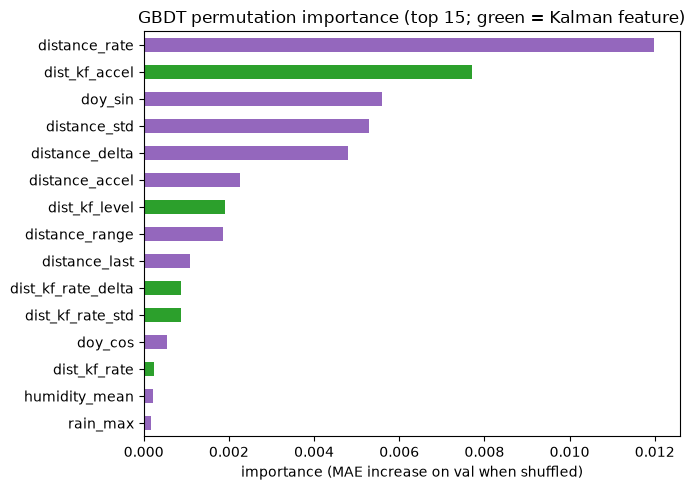

distance_rate         0.0120
dist_kf_accel         0.0077
doy_sin               0.0056
distance_std          0.0053
distance_delta        0.0048
distance_accel        0.0023
dist_kf_level         0.0019
distance_range        0.0019
distance_last         0.0011
dist_kf_rate_delta    0.0009
dist_kf_rate_std      0.0009
doy_cos               0.0005
dist_kf_rate          0.0002
humidity_mean         0.0002
rain_max              0.0002
Name: perm_importance, dtype: float64

In [24]:
imp = pd.read_csv(cfg.paths["reports"] / "feature_importance_gbdt.csv", index_col=0).iloc[:, 0].head(15)
colors = ["tab:green" if "_kf_" in n else "tab:purple" for n in imp.index][::-1]
ax = imp[::-1].plot.barh(figsize=(7, 5), color=colors)
ax.set_title("GBDT permutation importance (top 15; green = Kalman feature)")
ax.set_xlabel("importance (MAE increase on val when shuffled)")
plt.tight_layout(); plt.show()
imp.round(4)

## 8 — Live prediction

Code: [`src/minesub/predict.py`](../src/minesub/predict.py). `predict(readings, model=...)` takes a chronological
list of daily readings (`date`, `temp_c`, `humidity_pct`, `tilt_deg`, `distance_mm`), runs the **same**
backward-window (+ Kalman) feature extraction, and returns the **predicted excess settlement rate**, an
`alert` (`elevated` / `normal`) from the recall-tuned operating-point threshold learned at training time, the
fixed-geotech band, the horizon, and the raw rate/accel signals. Below: a fabricated *accelerating-settlement*
window — the shape an early-warning system must catch.

In [25]:
from minesub.predict import predict

n = max(cfg["features"]["backward_window_days"], cfg["model"]["torch"]["seq_len"]) + 5
dates = pd.date_range("2024-01-01", periods=n, freq="D")
readings = [
    {"date": dt.isoformat(),
     "temp_c":       float(18 + 6*np.sin(2*np.pi*i/365)),
     "humidity_pct": float(55 + 5*np.cos(2*np.pi*i/365)),
     "tilt_deg":     float(0.002*i + 2e-5*i*i),
     "distance_mm":  float(0.4*i + 0.01*i*i)}          # <- accelerating settlement
    for i, dt in enumerate(dates)
]
for model in ("gbdt", "torch"):
    print(f"--- predict ({model}) ---")
    print(json.dumps(predict(readings, model=model, cfg=cfg), indent=2))
    print()

--- predict (gbdt) ---
{
  "predicted_excess_rate_mm_day": 0.08647,
  "alert": "elevated",
  "operating_threshold_mm_day": 0.05096,
  "geotech_band": "safe",
  "horizon_days": 21,
  "model": "gbdt",
  "task": "regression",
  "signals": {
    "distance_rate": 0.79,
    "distance_accel": 0.02,
    "tilt_rate": 0.0028,
    "tilt_accel": 0.0,
    "dist_kf_rate": 1.06936,
    "dist_kf_accel": 0.01859
  },
  "as_of": "2024-02-04T00:00:00"
}

--- predict (torch) ---
{
  "predicted_excess_rate_mm_day": -0.01359,
  "alert": "normal",
  "operating_threshold_mm_day": 0.01093,
  "geotech_band": "safe",
  "horizon_days": 21,
  "model": "torch",
  "task": "regression",
  "signals": {},
  "as_of": "2024-02-04T00:00:00"
}



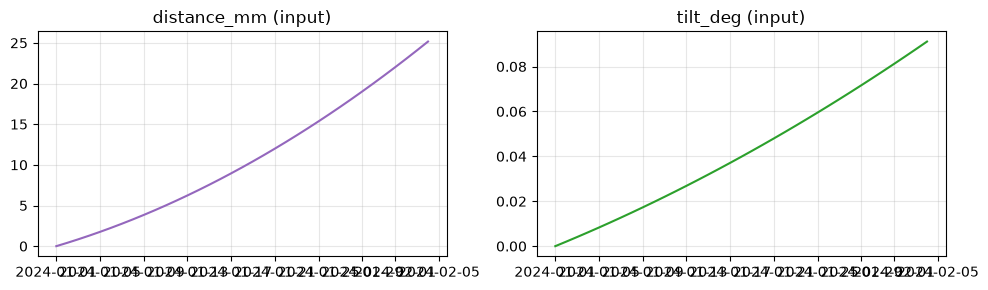

In [26]:
r = pd.DataFrame(readings); r["date"] = pd.to_datetime(r["date"])
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(r["date"], r["distance_mm"], color="tab:purple"); ax[0].set_title("distance_mm (input)")
ax[1].plot(r["date"], r["tilt_deg"], color="tab:green");     ax[1].set_title("tilt_deg (input)")
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Recap — what feeds what

```
CA DWR CKAN API ─┐
                 ├─ load_ground_displacement ─┐
station metadata ┘                            │
                                              ├─ build_timeseries ─► timeseries.parquet
Open-Meteo archive API ─ load_weather ────────┤   (daily resample + derived tilt + weather join)
                                              │
                          (synthetic fallback)┘
                                                     │
                       build_feature_table ◄─────────┘
                         backward 30d ─► features  (+ Kalman rate/accel)
                         forward  21d ─► fwd_* signals
                                              │
                            add_risk_labels ◄─┘  y_reg = forward excess settlement rate (mm/day)
                                              │
                            temporal_split ◄──┘  65 / 15 / 20 by time
                                              │
                    ┌─────────────────────────┴───────────────┐
          GbdtRiskModel (regressor)              LSTMRiskModel (regressor)
        windowed feature vector + Kalman            raw [30,4] sequence
                    │                                        │
              reports/metrics_gbdt.json              reports/metrics_torch.json
              (MAE / R2 / Spearman + recall-tuned operating point)
```

Re-run everything from a shell with:

```bash
.venv/bin/python -m minesub pipeline            # -> data/processed/*.parquet
.venv/bin/python -m minesub train --model both  # -> artifacts/models/, reports/
```